## 產生ArUco marker
下面範例產生ArUco marker影像，其中DICT_5X5_100表示Marker為5X5的黑白Bit-pattern，一共可有100個，編號0-99號。

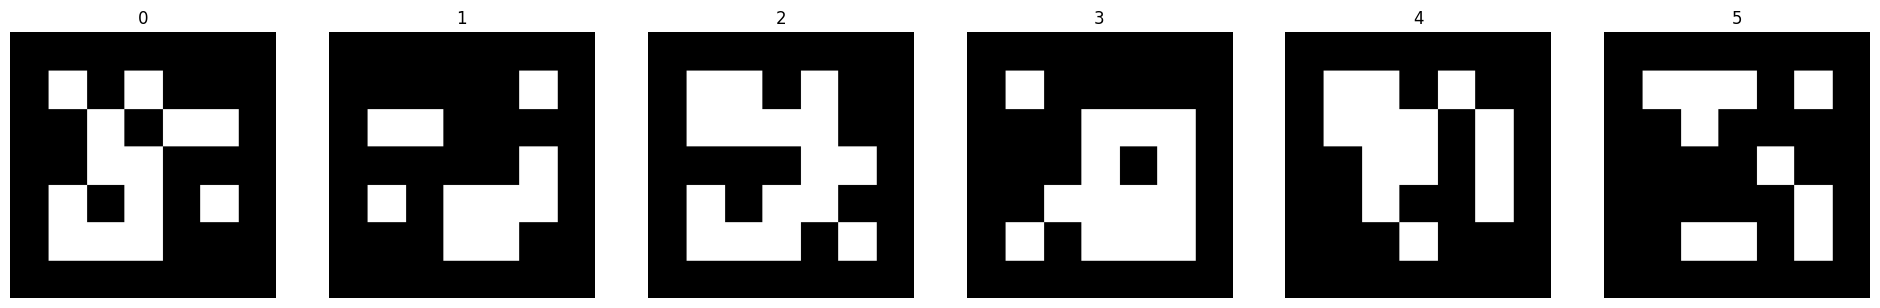

In [1]:
import cv2
import cv2.aruco as aruco
import matplotlib.pyplot as plt
arucoDict   = aruco.getPredefinedDictionary(aruco.DICT_5X5_100)
plt.figure(figsize=(24,4))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.title(i)    
    marker_image = aruco.generateImageMarker(arucoDict,i,200)
    plt.imshow(marker_image,cmap='gray')
    plt.axis(False)
plt.show()

下面範例產生ArUco marker影像，其中DICT_7X7_50表示Marker為7X7的黑白Bit-pattern，一共可有50個，編號0-49號。

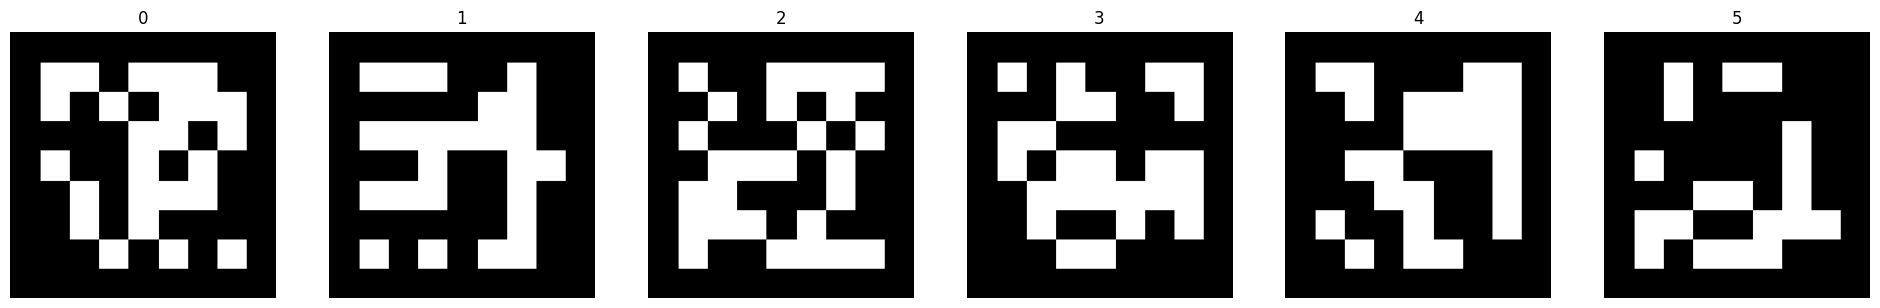

In [2]:
import cv2
import cv2.aruco as aruco
import matplotlib.pyplot as plt
arucoDict   = aruco.getPredefinedDictionary(aruco.DICT_7X7_50)

plt.figure(figsize=(24,4))
for i in range(0,6):
    plt.subplot(1,6,1+i)
    plt.title(i)    
    marker_image = aruco.generateImageMarker(arucoDict,i,200)
    plt.imshow(marker_image,cmap='gray')
    plt.axis(False)
plt.show()

到<a href="https://chev.me/arucogen/">這裡</a>或是用下面程式，產生特定尺寸(6cmX6cm)的ArUco Marker。

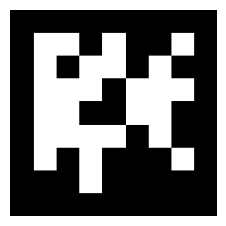

In [3]:
import cv2
import cv2.aruco as aruco
import matplotlib.pyplot as plt
arucoDict     = aruco.getPredefinedDictionary(aruco.DICT_7X7_50)
markerSize    = 6 # cm
markerId      = 6
plt.figure(figsize=(markerSize/2.54,markerSize/2.54))
marker_image = aruco.generateImageMarker(arucoDict,markerId,200)
plt.grid(False)
plt.axis(False)
plt.tight_layout()
plt.imshow(marker_image,cmap='gray')
plt.savefig('aruco_marker.svg')
plt.show()

### 產生ChArUco Marker
什麼是ChArUco board?詳細說明看<a href="https://docs.opencv.org/4.x/df/d4a/tutorial_charuco_detection.html">這裡</a>?
<img src="https://docs.opencv.org/4.x/charucodefinition.png" width="600px">

In [4]:
#help(aruco.CharucoBoard_create)

In [5]:
dir(aruco)

['ArucoDetector',
 'Board',
 'CORNER_REFINE_APRILTAG',
 'CORNER_REFINE_CONTOUR',
 'CORNER_REFINE_NONE',
 'CORNER_REFINE_SUBPIX',
 'CharucoBoard',
 'CharucoDetector',
 'CharucoParameters',
 'DICT_4X4_100',
 'DICT_4X4_1000',
 'DICT_4X4_250',
 'DICT_4X4_50',
 'DICT_5X5_100',
 'DICT_5X5_1000',
 'DICT_5X5_250',
 'DICT_5X5_50',
 'DICT_6X6_100',
 'DICT_6X6_1000',
 'DICT_6X6_250',
 'DICT_6X6_50',
 'DICT_7X7_100',
 'DICT_7X7_1000',
 'DICT_7X7_250',
 'DICT_7X7_50',
 'DICT_APRILTAG_16H5',
 'DICT_APRILTAG_16h5',
 'DICT_APRILTAG_25H9',
 'DICT_APRILTAG_25h9',
 'DICT_APRILTAG_36H10',
 'DICT_APRILTAG_36H11',
 'DICT_APRILTAG_36h10',
 'DICT_APRILTAG_36h11',
 'DICT_ARUCO_MIP_36H12',
 'DICT_ARUCO_MIP_36h12',
 'DICT_ARUCO_ORIGINAL',
 'DetectorParameters',
 'Dictionary',
 'Dictionary_getBitsFromByteList',
 'Dictionary_getByteListFromBits',
 'GridBoard',
 'RefineParameters',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_native',
 'drawDetectedCornersCharuco

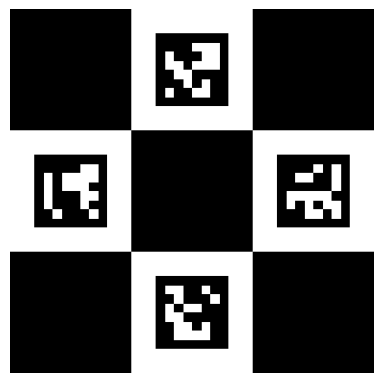

In [6]:
import numpy as np
arucoDict = aruco.getPredefinedDictionary(aruco.DICT_6X6_250)
arucoIds  = np.array([13,29,47,97])
squareLength= 200
markerLength= 120
markerSize  = 10 # cm
charucoBoard = aruco.CharucoBoard((3,3),squareLength,markerLength,arucoDict)
markerImage = charucoBoard.generateImage((3*100,3*100),0,0) # Square 100x100 pixels
#markerImage = aruco.drawCharucoDiamond(arucoDict,arucoIds,squareLength,markerLength)
plt.figure(figsize=(markerSize/2.54,markerSize/2.54))
plt.axis(False)
plt.grid(False)
plt.tight_layout()
plt.imshow(markerImage,cmap='gray')
plt.savefig('ChArUco_marker.svg')
plt.show()

## 使用ChArUco或ArUco Marker做相機校正

### 產生ArUco Board。

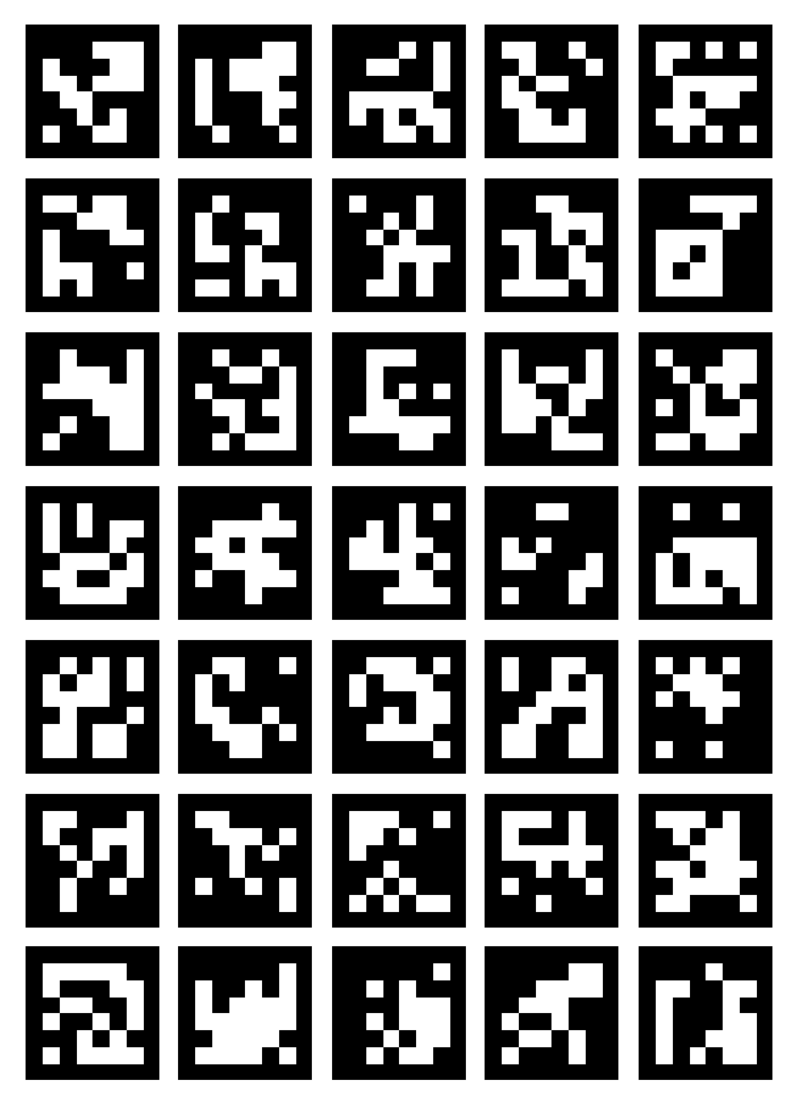

In [8]:
import numpy as np
arucoDict    = aruco.getPredefinedDictionary(aruco.DICT_6X6_250)
gridX        = 5
gridY        = 7
markerSize   = 3.5 #cm
markerGap    = 0.5 #cm
arucoBoard   = aruco.GridBoard((gridX,gridY),markerSize,markerGap,arucoDict) # marker:3.5cmx3.5cm,間隔0.5cm
boardImage   = arucoBoard.generateImage((gridX*100,gridY*100),marginSize=10) #5*100,7*100
boardHeight  = gridY*markerSize+(gridY+1)*markerGap #cm
boardWidth   = gridX*markerSize+(gridX+1)*markerGap
plt.figure(figsize=(boardWidth/2.54,boardHeight/2.54))
plt.grid(False)
plt.axis(False)
plt.tight_layout()
plt.imshow(boardImage,cmap='gray')
plt.savefig('ArUco_board.svg')
plt.show()

### 產生ChArUco Board。
根據官方說明，偵測ChArUco board比較準。

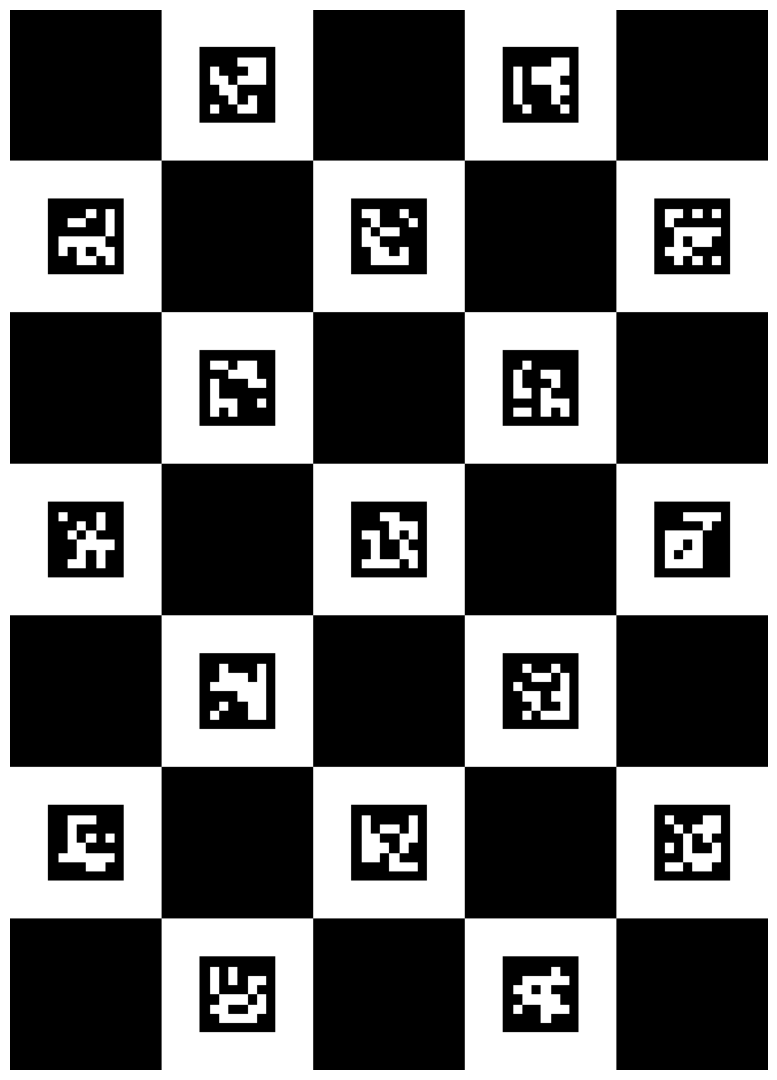

In [9]:
import numpy as np
arucoDict    = aruco.getPredefinedDictionary(aruco.DICT_6X6_250)
gridX        = 5
gridY        = 7
squareSize   = 4 #cm
charucoBoard = aruco.CharucoBoard((gridX,gridY),squareSize,squareSize/2,arucoDict)
boardImage   = charucoBoard.generateImage((gridX*100,gridY*100),0,0) # Square 100x100 pixels
plt.figure(figsize=(gridX*squareSize/2.54,gridY*squareSize/2.54)) #Board 5*4cm X 7*4cm
plt.grid(False)
plt.axis(False)
plt.tight_layout()
plt.imshow(boardImage,cmap='gray')
plt.savefig('ChArUco_board.svg')
plt.show()

## 偵測ArUco Marker

使用前先準備有關aruco影像處理與marker編碼的參數。有必要，可以調整影像處理的參數arucoParams:
<code>
   arucoParams = aruco.DetectorParameters()
   arucoDict   = aruco.getPredefinedDictionary(aruco.DICT_7X7_50)
   detector    = aruco.ArucoDetector(arucoDict, arucoParams)   
</code>
然後呼叫偵測aruco marker函式:
<code>    
   (corners, ids, rejected) = detector.detectMarkers(frame)
</code>
若要顯示偵測結果，可以呼叫drawDetectedMarkers
<code>
   aruco.drawDetectedMarkers(frame, corners, ids)        
</code>    
corners依照順時針排，但是沒說哪一個角是第一個點。

In [10]:
dir(aruco)

['ArucoDetector',
 'Board',
 'CORNER_REFINE_APRILTAG',
 'CORNER_REFINE_CONTOUR',
 'CORNER_REFINE_NONE',
 'CORNER_REFINE_SUBPIX',
 'CharucoBoard',
 'CharucoDetector',
 'CharucoParameters',
 'DICT_4X4_100',
 'DICT_4X4_1000',
 'DICT_4X4_250',
 'DICT_4X4_50',
 'DICT_5X5_100',
 'DICT_5X5_1000',
 'DICT_5X5_250',
 'DICT_5X5_50',
 'DICT_6X6_100',
 'DICT_6X6_1000',
 'DICT_6X6_250',
 'DICT_6X6_50',
 'DICT_7X7_100',
 'DICT_7X7_1000',
 'DICT_7X7_250',
 'DICT_7X7_50',
 'DICT_APRILTAG_16H5',
 'DICT_APRILTAG_16h5',
 'DICT_APRILTAG_25H9',
 'DICT_APRILTAG_25h9',
 'DICT_APRILTAG_36H10',
 'DICT_APRILTAG_36H11',
 'DICT_APRILTAG_36h10',
 'DICT_APRILTAG_36h11',
 'DICT_ARUCO_MIP_36H12',
 'DICT_ARUCO_MIP_36h12',
 'DICT_ARUCO_ORIGINAL',
 'DetectorParameters',
 'Dictionary',
 'Dictionary_getBitsFromByteList',
 'Dictionary_getByteListFromBits',
 'GridBoard',
 'RefineParameters',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_native',
 'drawDetectedCornersCharuco

In [3]:
import cv2
import cv2.aruco as aruco

cap = cv2.VideoCapture('arUco_marker.mp4')
#原始畫面有點大，為了有利於顯示這份講義所以縮小。
frameWidth   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))//2
frameHeight  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))//2

arucoParams = aruco.DetectorParameters()#DetectorParameters_create()
arucoDict   = aruco.getPredefinedDictionary(aruco.DICT_7X7_50) #Dictionary_get(aruco.DICT_7X7_50)
# Create the ArUco detector
detector = cv2.aruco.ArucoDetector(arucoDict, arucoParams)

print('height {}, width {}'.format(cap.get(cv2.CAP_PROP_FRAME_HEIGHT),cap.get(cv2.CAP_PROP_FRAME_WIDTH)))

while True:
    ret, frame = cap.read()
    if not ret:
        break
        
    frame = cv2.resize(frame,(frameWidth,frameHeight)) 
    (corners, ids, rejected) = detector.detectMarkers(frame)     
    if len(corners) > 0:
        aruco.drawDetectedMarkers(frame, corners, ids)
        
    cv2.imshow('arUco marker',frame)
    if cv2.waitKey(20) != -1:
        break

cv2.destroyAllWindows()
cap.release()

height 1080.0, width 1920.0


KeyboardInterrupt: 

## 使用未校正相機估計ChArUco Board姿態
相機內部參數先用猜的。

In [4]:
import cv2
import cv2.aruco as aruco
import numpy as np
cap = cv2.VideoCapture('CharUco_board.mp4')
print('height {}, width {}'.format(cap.get(cv2.CAP_PROP_FRAME_HEIGHT),cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
#原始畫面有點大，為了有利於顯示這份講義所以縮小。    
totalFrame   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frameWidth   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))//2
frameHeight  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))//2

arucoParams = aruco.DetectorParameters()#DetectorParameters_create()
arucoParams.cornerRefinementMethod = aruco.CORNER_REFINE_SUBPIX
arucoDict   = aruco.getPredefinedDictionary(aruco.DICT_6X6_250) #Dictionary_get(aruco.DICT_7X7_50)
# Create the ArUco detector
detector = aruco.ArucoDetector(arucoDict, arucoParams)

# Create the CharucoBoard
gridX        = 5
gridY        = 7
squareSize   = 4 #cm
charucoBoard = aruco.CharucoBoard((gridX,gridY),squareSize,squareSize/2,arucoDict)

cameraMatrixInit = np.array([[ frameWidth/2.,    0., frameWidth/2.],[    0., frameWidth/2., frameHeight/2.],[    0.,    0.,           1.]])
distCoeffsInit   = np.zeros((5,1))

charucoParams = aruco.CharucoParameters()
charucoParams.tryRefineMarkers = True
charucoParams.cameraMatrix = cameraMatrixInit
charucoParams.distCoeffs = distCoeffsInit
charucoDetector = aruco.CharucoDetector(charucoBoard, charucoParams,arucoParams)

while True:
    ret, frame = cap.read()
    if not ret:
        break
           
    frame = cv2.resize(frame,(frameWidth,frameHeight)) 
    corners, ids, _, _ = charucoDetector.detectBoard(frame)
    
    if ids is not None and len(ids)>0:
        aruco.drawDetectedCornersCharuco(frame,corners, ids)
        objPoints, imgPoints = charucoBoard.matchImagePoints(corners, ids)
        if objPoints.shape[0]>=4:
            ret, rvect, tvect = cv2.solvePnP(objPoints, imgPoints, cameraMatrixInit, distCoeffsInit) 
            if ret:
                cv2.drawFrameAxes(frame, cameraMatrixInit, distCoeffsInit, rvect, tvect, squareSize)
        
    cv2.imshow('Estimation of the pose of a ChArUco board with inarrurate intrinic camera parameters',frame)
    if cv2.waitKey(20) != -1:
        break
        
cv2.destroyAllWindows()
cap.release()

height 1080.0, width 1920.0


KeyboardInterrupt: 

### 使用ChArUco Board做相機校正

In [5]:
import cv2
import cv2.aruco as aruco

cap = cv2.VideoCapture('CharUco_board.mp4')
#原始畫面有點大，為了有利於顯示這份講義所以縮小。    
totalFrame   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frameWidth   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))//2
frameHeight  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))//2

arucoParams = aruco.DetectorParameters()
arucoParams.cornerRefinementMethod = aruco.CORNER_REFINE_SUBPIX
arucoDict   = aruco.getPredefinedDictionary(aruco.DICT_6X6_250) 

# Create the ArUco detector
detector = cv2.aruco.ArucoDetector(arucoDict, arucoParams)

# 必須描述ChArUco board的尺寸規格
gridX        = 5 # 水平方向5格
gridY        = 7 # 垂直方向7格
squareSize   = 4 # 每格為4cmX4cm

# ArUco marker為2cmX2cm
charucoBoard = aruco.CharucoBoard((gridX,gridY),squareSize,squareSize/2,arucoDict)

charucoParams = aruco.CharucoParameters()
charucoParams.tryRefineMarkers = True
charucoParams.cameraMatrix = cameraMatrixInit
charucoParams.distCoeffs = distCoeffsInit
charucoDetector = aruco.CharucoDetector(charucoBoard, charucoParams,arucoParams)

print('height {}, width {}'.format(cap.get(cv2.CAP_PROP_FRAME_HEIGHT),cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
refinedStrategy = True
criteria        = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.00001)
frameId        = 0
objPointsList  = []
imgPointsList  = []

while True:
    ret, frame = cap.read()
    if not ret:
        break
        
    frame = cv2.resize(frame,(frameWidth,frameHeight)) 
    corners, ids, _, _ = charucoDetector.detectBoard(frame)

    if corners is not None and corners.shape[0]>0:
        aruco.drawDetectedCornersCharuco(frame,corners, ids)
        objPoints, imgPoints = charucoBoard.matchImagePoints(corners, ids)
    
        if frameId % 100==50 and objPoints.shape[0]>=4: 
            objPointsList.append(objPoints)
            imgPointsList.append(imgPoints)

    cv2.imshow('Analysis of a CharUco board for camera calibration',frame)
    if cv2.waitKey(20) != -1:
        break
        
    frameId += 1

cv2.destroyAllWindows()
cap.release()

height 1080.0, width 1920.0


KeyboardInterrupt: 

### 使用cv2.calibrateCamera 執行相機校正

In [6]:
cameraMatrixInit = np.array([[ 1000.,    0., frameWidth/2.],[    0., 1000., frameHeight/2.],[    0.,    0.,           1.]])
distCoeffsInit   = np.zeros((5,1))
ret, charuco_cameraMatrix, charuco_distCoeffs, aruco_rvects, aruco_tvects = cv2.calibrateCamera(objPointsList,imgPointsList,(frameWidth,frameHeight),cameraMatrixInit,distCoeffsInit)
print(charuco_cameraMatrix)
print(charuco_distCoeffs)

[[1.12313718e+03 0.00000000e+00 4.70380484e+02]
 [0.00000000e+00 1.15651803e+03 2.67929002e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
[[-3.55894383e-01]
 [ 1.68962438e+01]
 [-7.09282352e-03]
 [-5.11008157e-03]
 [-1.90802020e+02]]


### 使用校正的相機估計ChArUco Board姿態

In [ ]:
import cv2
import cv2.aruco as aruco

cap = cv2.VideoCapture('CharUco_board.mp4')
print('height {}, width {}'.format(cap.get(cv2.CAP_PROP_FRAME_HEIGHT),cap.get(cv2.CAP_PROP_FRAME_WIDTH)))

#原始畫面有點大，為了有利於顯示這份講義所以縮小。    
totalFrame   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frameWidth   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))//2
frameHeight  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))//2

arucoParams = aruco.DetectorParameters()
arucoParams.cornerRefinementMethod = aruco.CORNER_REFINE_SUBPIX
arucoDict   = aruco.getPredefinedDictionary(aruco.DICT_6X6_250) #Dictionary_get(aruco.DICT_7X7_50)

# Create the ArUco detector
detector = cv2.aruco.ArucoDetector(arucoDict, arucoParams)

gridX        = 5
gridY        = 7
squareSize   = 4 #cm
charucoBoard = aruco.CharucoBoard((gridX,gridY),squareSize,squareSize/2,arucoDict)

charucoParams = aruco.CharucoParameters()
charucoParams.tryRefineMarkers = True
charucoParams.cameraMatrix = charuco_cameraMatrix
charucoParams.distCoeffs = charuco_distCoeffs
charucoDetector = aruco.CharucoDetector(charucoBoard, charucoParams,arucoParams)

while True:
    ret, frame = cap.read()
    if not ret:
        break
        
    frame = cv2.resize(frame,(frameWidth,frameHeight)) 
    corners, ids, _, _ = charucoDetector.detectBoard(frame)

    if corners is not None and corners.shape[0]>0:
        aruco.drawDetectedCornersCharuco(frame,corners, ids)
        objPoints, imgPoints = charucoBoard.matchImagePoints(corners, ids)
        if objPoints is not None and objPoints.shape[0]>=4:
            ret, rvect, tvect = cv2.solvePnP(objPoints, imgPoints, charuco_cameraMatrix, charuco_distCoeffs) #aruco.estimatePoseBoard(corners, ids, charucoBoard, cameraMatrixInit, distCoeffsInit, None, None)
            if ret:
                cv2.drawFrameAxes(frame, charuco_cameraMatrix, charuco_distCoeffs, rvect, tvect, squareSize)
        
    cv2.imshow('Estimation of the pose of a CharUco board with intrinsic camera parameters',frame)
    if cv2.waitKey(20) != -1:
        break
        
cv2.destroyAllWindows()
cap.release()

height 1080.0, width 1920.0


KeyboardInterrupt: 

: 

### 估計Marker姿態

In [7]:
import cv2
import cv2.aruco as aruco

cap = cv2.VideoCapture('arUco_marker.mp4')
markerSize  = 6 #6cm

#原始畫面有點大，為了有利於顯示這份講義所以縮小。    
frameWidth   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))//2
frameHeight  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))//2

arucoParams = aruco.DetectorParameters()
arucoParams.cornerRefinementMethod = aruco.CORNER_REFINE_SUBPIX
arucoDict   = aruco.getPredefinedDictionary(aruco.DICT_7X7_50)

# Create the ArUco detector
detector = cv2.aruco.ArucoDetector(arucoDict, arucoParams)

print('height {}, width {}'.format(cap.get(cv2.CAP_PROP_FRAME_HEIGHT),cap.get(cv2.CAP_PROP_FRAME_WIDTH)))

objPoints = np.array([[0.0,0.0,0.0],[markerSize,0.0,0.0],[markerSize,markerSize,0.0],[0.0,markerSize,0.0]],dtype=np.float32)
objPoints = np.array([[markerSize/2,markerSize/2,0],[-markerSize/2,markerSize/2,0],[-markerSize/2,-markerSize/2,0],[markerSize/2,-markerSize/2,0]],dtype=float)
while True:
    ret, frame = cap.read()
    if not ret:
        break
           
    frame = cv2.resize(frame,(frameWidth,frameHeight)) 
    (corners, ids, rejected) = detector.detectMarkers(frame)    
    if len(corners) > 0:
        aruco.drawDetectedMarkers(frame, corners, ids)
        for i in range(len(corners)):
            ret, rvect, tvect = cv2.solvePnP(objPoints, corners[i][0], charuco_cameraMatrix, charuco_distCoeffs) #aruco.estimatePoseBoard(corners, ids, charucoBoard, cameraMatrixInit, distCoeffsInit, None, None)
            cv2.drawFrameAxes(frame, charuco_cameraMatrix, charuco_distCoeffs, rvect, tvect, markerSize/2)
        
    cv2.imshow('Estimation of the pose of arUco marker with intrinsic camera parameters',frame)
    if cv2.waitKey(20) != -1:
        break

cv2.destroyAllWindows()
cap.release()

height 1080.0, width 1920.0


KeyboardInterrupt: 

## 世界座標系統$\Rightarrow$影像座標系統
將Marker的4角點透過projectPoints計算其影像座標。

In [ ]:
import cv2
import cv2.aruco as aruco

cap = cv2.VideoCapture('arUco_marker.mp4')
markerSize  = 6 #6cm

#原始畫面有點大，為了有利於顯示這份講義所以縮小。    
frameWidth   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))//2
frameHeight  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))//2

arucoParams = aruco.DetectorParameters()
arucoParams.cornerRefinementMethod = aruco.CORNER_REFINE_SUBPIX
arucoDict   = aruco.getPredefinedDictionary(aruco.DICT_7X7_50)

print('height {}, width {}'.format(cap.get(cv2.CAP_PROP_FRAME_HEIGHT),cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
markerCorners3D = np.array([[markerSize/2,markerSize/2,0],[-markerSize/2,markerSize/2,0],[-markerSize/2,-markerSize/2,0],[markerSize/2,-markerSize/2,0]],dtype=float)

# Create the ArUco detector
detector = cv2.aruco.ArucoDetector(arucoDict, arucoParams)

while True:
    ret, frame = cap.read()
    if not ret:
        break
           
    frame = cv2.resize(frame,(frameWidth,frameHeight)) 
    (corners, ids, rejected) = detector.detectMarkers(frame)    

    if len(corners) > 0:
        aruco.drawDetectedMarkers(frame, corners, ids)
        for corner in corners:
            for pt in corner[0]:
                cv2.drawMarker(frame,tuple(pt.astype(int).ravel()),(0,0,255),cv2.MARKER_CROSS,20,2)

        for i in range(len(corners)):
            ret, rvect, tvect = cv2.solvePnP(markerCorners3D, corners[i][0], charuco_cameraMatrix, charuco_distCoeffs)         
            proj_pt_with_dist,_ = cv2.projectPoints(markerCorners3D, rvect, tvect, charuco_cameraMatrix, charuco_distCoeffs)
            cv2.drawFrameAxes(frame, charuco_cameraMatrix, charuco_distCoeffs, rvect, tvect, markerSize/2)
            for pt in proj_pt_with_dist:
                cv2.drawMarker(frame,tuple(pt.astype(int).ravel()),(0,255,0),cv2.MARKER_CROSS,10,2)
        
    cv2.imshow('Estimation of the pose of arUco marker with intrinsic camera parameters',frame)
    if cv2.waitKey(20) != -1:
        break

cv2.destroyAllWindows()
cap.release()